In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [2]:
df=pd.read_csv('synthetic_personal_finance_dataset.csv')

In [3]:
df.columns 

Index(['user_id', 'age', 'gender', 'education_level', 'employment_status',
       'job_title', 'monthly_income_usd', 'monthly_expenses_usd',
       'savings_usd', 'has_loan', 'loan_type', 'loan_amount_usd',
       'loan_term_months', 'monthly_emi_usd', 'loan_interest_rate_pct',
       'debt_to_income_ratio', 'credit_score', 'savings_to_income_ratio',
       'region', 'record_date'],
      dtype='object')

In [4]:
df.head()

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,NaN,0.00,0,0.00,0.00,0.00,430,8.68,Other,2024-01-09
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,543,6.16,North America,2022-02-13
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,NaN,0.00,0,0.00,0.00,0.00,754,6.87,Africa,2022-05-12
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,461,4.31,Europe,2023-10-02
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,NaN,0.00,0,0.00,0.00,0.00,516,7.50,Africa,2021-08-07


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  32424 non-null  object 
 1   age                      32424 non-null  int64  
 2   gender                   32424 non-null  object 
 3   education_level          32424 non-null  object 
 4   employment_status        32424 non-null  object 
 5   job_title                32424 non-null  object 
 6   monthly_income_usd       32424 non-null  float64
 7   monthly_expenses_usd     32424 non-null  float64
 8   savings_usd              32424 non-null  float64
 9   has_loan                 32424 non-null  object 
 10  loan_type                12995 non-null  object 
 11  loan_amount_usd          32424 non-null  float64
 12  loan_term_months         32424 non-null  int64  
 13  monthly_emi_usd          32424 non-null  float64
 14  loan_interest_rate_pct

In [6]:
df.isnull().sum()

user_id                        0
age                            0
gender                         0
education_level                0
employment_status              0
job_title                      0
monthly_income_usd             0
monthly_expenses_usd           0
savings_usd                    0
has_loan                       0
loan_type                  19429
loan_amount_usd                0
loan_term_months               0
monthly_emi_usd                0
loan_interest_rate_pct         0
debt_to_income_ratio           0
credit_score                   0
savings_to_income_ratio        0
region                         0
record_date                    0
dtype: int64

In [7]:
df['loan_type'].fillna('No loan',inplace=True)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14400\121340140.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_type'].fillna('No loan',inplace=True)


In [8]:
df.dropna()

,user_id,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region,record_date
0,U00001,56,Female,High School,Self-employed,Salesperson,3531.69,1182.59,367655.03,No,No loan,0.00,0,0.00,0.00,0.00,430,8.68,Other,2024-01-09
1,U00002,19,Female,PhD,Employed,Salesperson,3531.73,2367.99,260869.10,Yes,Education,146323.34,36,4953.50,13.33,1.40,543,6.16,North America,2022-02-13
2,U00003,20,Female,Master,Employed,Teacher,2799.49,1003.91,230921.21,No,No loan,0.00,0,0.00,0.00,0.00,754,6.87,Africa,2022-05-12
3,U00004,25,Male,PhD,Employed,Manager,5894.88,4440.12,304815.51,Yes,Business,93242.37,24,4926.57,23.93,0.84,461,4.31,Europe,2023-10-02
4,U00005,53,Female,PhD,Employed,Student,5128.93,4137.61,461509.48,No,No loan,0.00,0,0.00,0.00,0.00,516,7.50,Africa,2021-08-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32419,U32420,30,Female,High School,Employed,Salesperson,4266.87,1510.82,273669.70,Yes,Car,498400.74,120,6227.54,8.68,1.46,434,5.34,Europe,2024-02-25
32420,U32421,51,Female,Master,Employed,Student,5725.78,4965.02,17247.57,Yes,Home,83602.57,12,7605.13,16.50,1.33,453,0.25,North America,2025-06-06
32421,U32422,18,Female,Bachelor,Self-employed,Doctor,3282.38,2243.77,22081.21,No,No loan,0.00,0,0.00,0.00,0.00,391,0.56,Other,2025-07-20
32422,U32423,36,Other,High School,Self-employed,Accountant,5035.99,4054.32,524039.88,No,No loan,0.00,0,0.00,0.00,0.00,596,8.67,Asia,2022-06-07


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['loan_type'] = df['loan_type'].fillna('No Loan')

In [11]:
df['record_date']=pd.to_datetime(df['record_date'])

<Axes: >

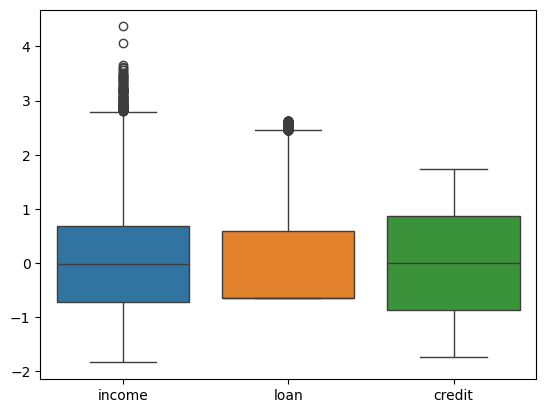

In [12]:
scaler = StandardScaler()
scaled = scaler.fit_transform(df[['monthly_income_usd','loan_amount_usd','credit_score']])

scaled_df = pd.DataFrame(scaled, columns=['income','loan','credit'])

sns.boxplot(data=scaled_df)

In [13]:
Q1 = df['loan_amount_usd'].quantile(0.25)
Q3 = df['loan_amount_usd'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df['loan_amount_usd'] = df['loan_amount_usd'].clip(lower, upper)

In [14]:
df.isnull().sum()

user_id                    0
age                        0
gender                     0
education_level            0
employment_status          0
job_title                  0
monthly_income_usd         0
monthly_expenses_usd       0
savings_usd                0
has_loan                   0
loan_type                  0
loan_amount_usd            0
loan_term_months           0
monthly_emi_usd            0
loan_interest_rate_pct     0
debt_to_income_ratio       0
credit_score               0
savings_to_income_ratio    0
region                     0
record_date                0
dtype: int64

In [15]:
df.fillna(df.select_dtypes(include='number').mean(), inplace=True)

In [16]:
df.describe()

,age,monthly_income_usd,monthly_expenses_usd,savings_usd,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,record_date
count,32424.000000,32424.000000,32424.000000,3.242400e+04,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424.000000,32424
mean,43.415865,4027.863185,2419.444709,2.437520e+05,99856.551803,58.500000,3092.992339,6.616332,1.194881,575.260424,5.045431,2023-07-24 02:38:14.300518144
min,18.000000,500.000000,150.010000,6.359600e+02,0.000000,0.000000,0.000000,0.000000,0.000000,300.000000,0.100000,2021-07-23 00:00:00
25%,30.000000,2657.795000,1397.497500,8.629155e+04,0.000000,0.000000,0.000000,0.000000,0.000000,437.000000,2.580000,2022-07-22 00:00:00
50%,43.000000,3997.740000,2219.575000,2.017003e+05,0.000000,0.000000,0.000000,0.000000,0.000000,575.000000,5.040000,2023-07-24 00:00:00
75%,56.000000,5351.607500,3254.037500,3.589662e+05,189499.070000,60.000000,3574.567500,13.140000,0.920000,714.000000,7.510000,2024-07-22 00:00:00
max,69.000000,12404.050000,10082.710000,1.237774e+06,473747.675000,360.000000,47723.840000,30.000000,90.670000,850.000000,10.000000,2025-07-22 00:00:00
std,14.978246,1916.773353,1388.893084,1.915772e+05,151887.926941,104.865373,6478.939776,9.472964,3.761964,159.023227,2.851344,NaN


<Axes: >

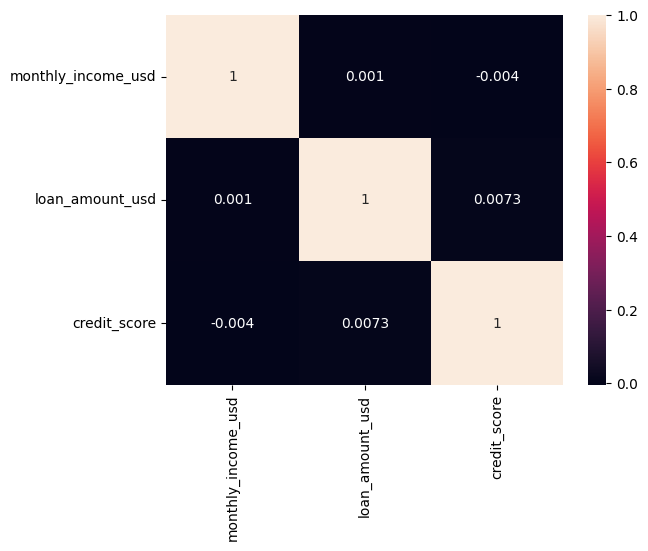

In [17]:
num_df = df[['monthly_income_usd', 'loan_amount_usd', 'credit_score']]
sns.heatmap(num_df.corr(), annot=True)

<Axes: >

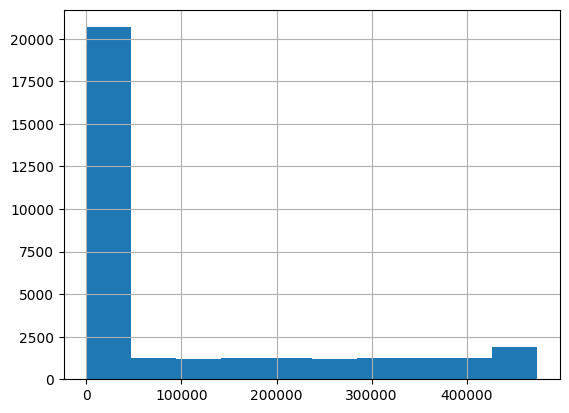

In [18]:
df['loan_amount_usd'].hist()

<Axes: xlabel='loan_type', ylabel='count'>

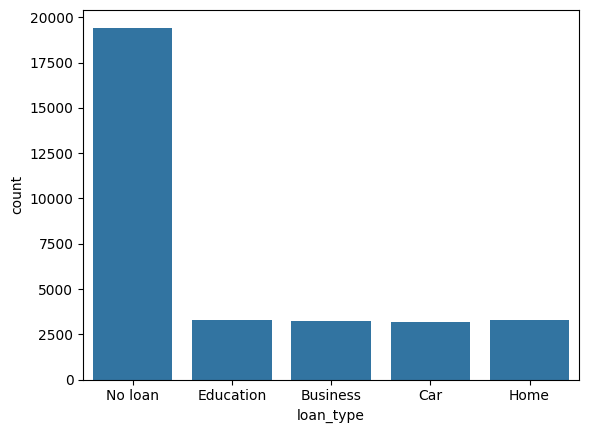

In [19]:
sns.countplot(x=df['loan_type'])

In [20]:
df['income_to_loan_ratio'] = df['monthly_income_usd'] / df['loan_amount_usd']

In [21]:
df['income_to_loan_ratio'].describe()

C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\numpy\lib\_function_base_impl.py:4596: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = b - a


count    3.242400e+04
mean              inf
std               NaN
min      1.055414e-03
25%      2.144646e-02
50%               NaN
75%               NaN
max               inf
Name: income_to_loan_ratio, dtype: float64

<Axes: xlabel='income_to_loan_ratio', ylabel='Count'>

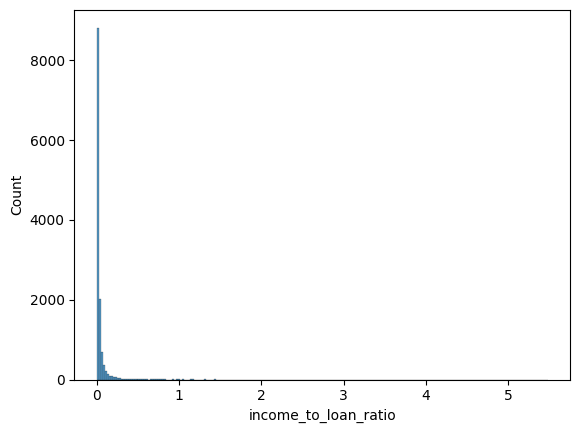

In [22]:
sns.histplot(df['income_to_loan_ratio'])

<Axes: xlabel='income_to_loan_ratio'>

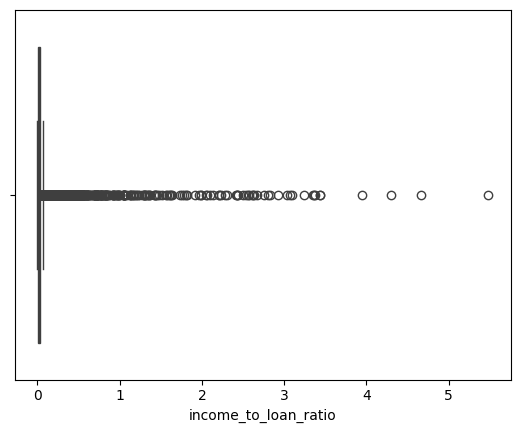

In [23]:
sns.boxplot(x=df['income_to_loan_ratio'])

In [24]:
df.groupby('loan_type')['income_to_loan_ratio'].mean()

loan_type
Business     0.051161
Car          0.053510
Education    0.050987
Home         0.054384
No loan           inf
Name: income_to_loan_ratio, dtype: float64

In [26]:
df.groupby('employment_status')['income_to_loan_ratio'].mean()

employment_status
Employed         inf
Self-employed    inf
Student          inf
Unemployed       inf
Name: income_to_loan_ratio, dtype: float64

<Axes: xlabel='income_to_loan_ratio', ylabel='loan_amount_usd'>

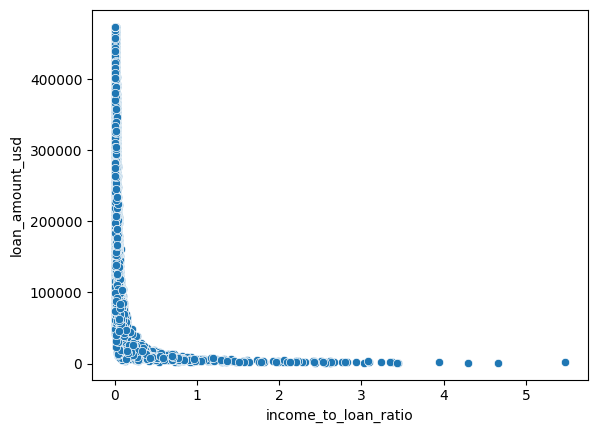

In [27]:
sns.scatterplot(x=df['income_to_loan_ratio'], y=df['loan_amount_usd'])

<Axes: >

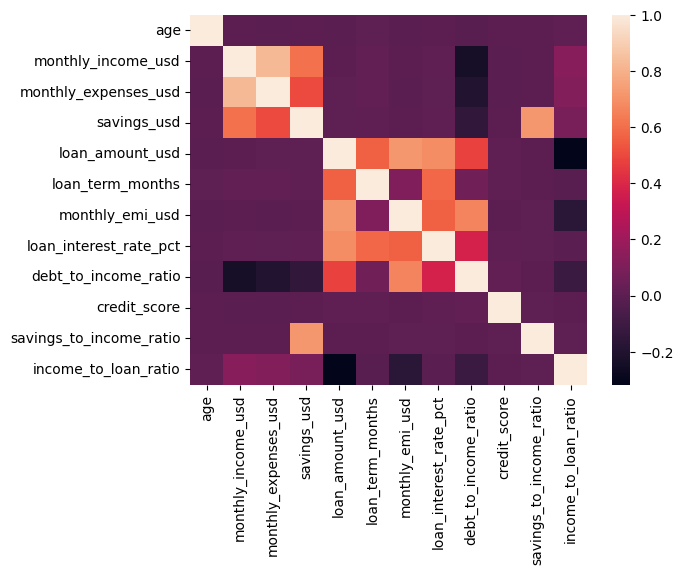

In [24]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=False)

In [25]:
df.groupby('loan_type')['loan_amount_usd'].mean()

df.groupby('employment_status')['monthly_income_usd'].mean()

df.groupby('region')['loan_amount_usd'].sum()

region
Africa           6.335396e+08
Asia             6.534314e+08
Europe           6.675959e+08
North America    6.518519e+08
Other            6.397014e+08
Name: loan_amount_usd, dtype: float64

<Axes: xlabel='monthly_income_usd', ylabel='loan_amount_usd'>

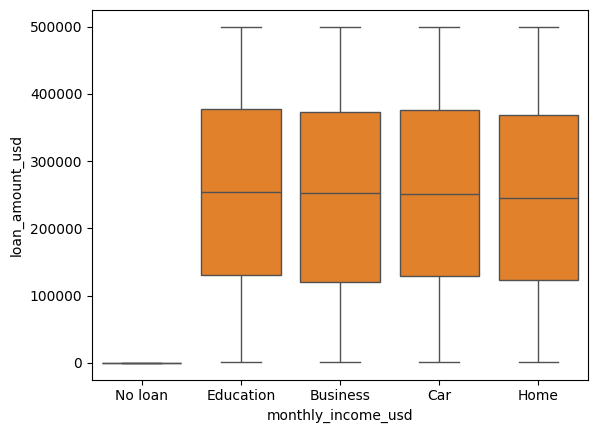

In [27]:
sns.scatterplot(x=df['monthly_income_usd'], y=df['loan_amount_usd'])

sns.boxplot(x=df['loan_type'], y=df['loan_amount_usd'])
